# Example 2 &ndash; Coupled Simulation

This example builds on the acoustic simulation from Example 1, if you haven't done so already, ***please run Example 1 before running this one.***


In [1]:
import xarray as xr
import numpy as np

from frequensolve import *

project = Project.copy(
    src = "scratch/ex_01/project.json", 
    dest = "scratch/ex_02/",
    name = "ex_02",
    pretty_name = "Coupled Simulation"
)

## Coupled Physics

SeismicSimulation currently supports the following `physics`:

- `acoustic`
- `elastic`
- `coupled`

Attenuation is supported by simply specifying `Qp` and `Qs` (no special distinction is made for visco-acoustic and
viso-elastic physics since attenuation simply introduces a complex-valued wavespeed). For coupled physics, the physics
can specified per-subdomain (layer) via the `physics`; otherwise the physics is indicated by whether or not elastic properties are specified on the subdomain. 

In the following we change Example 1 physics to `coupled` and convert the lower layer to an elastic domain.

surfaces:
 ['top', 'interface', 'bottom']
layers:
 ['layer_1', 'layer_2']


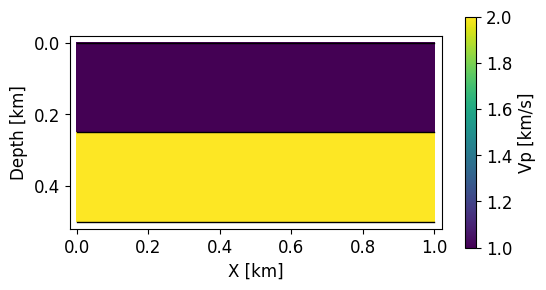

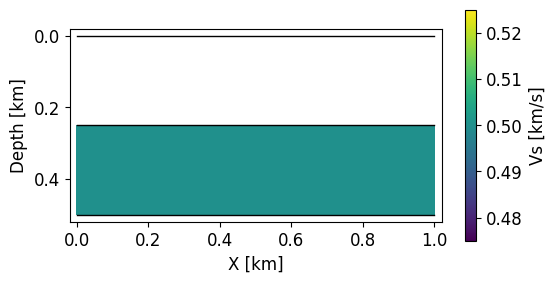

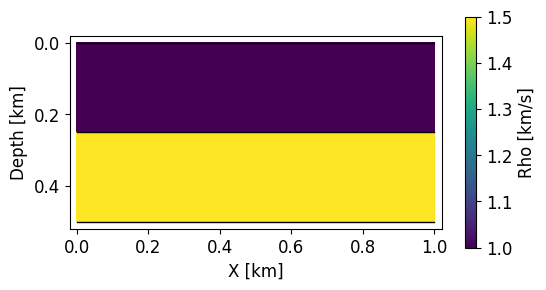

In [2]:

# Copy the simulation but change the physics to "coupled"
sim = project.simulations["simple_acoustic"].copy(
    name = "simple_coupled",
    physics = "coupled",
    dimension = 2,
)
del project.simulations[0]
project += sim

model = sim.model

print("surfaces:\n", model.surface_names)
print("layers:\n", model.layer_names)

layer1 = model.layers["layer_1"]
layer1.name = "fluid"
layer1.physics = "acoustic"
layer1.properties = {
    "Vp" : 1.0, 
    "Qp" : 200.0, 
    "Rho": 1.0
}

layer2 = model.layers["layer_2"]
layer2.name = "solid"
layer2.physics = "elastic"
layer2.properties = {
    "Vp" : 2.0, 
    "Qp" : 100.0, 
    "Vs" : 0.5,
    "Qs" : 50.0,
    "Rho": 1.5
}

model.plot("Vp",figsize=(6,3),aspect="equal")
model.plot("Vs",figsize=(6,3),aspect="equal")
model.plot("Rho",figsize=(6,3),aspect="equal")

## Heterogeneity

Heterogeneity can be added via the `perturb` function of both layers and surfaces (`perturb` is a thin wrapper
for the Von Karman stochastic field functions in `frequensolve.utils.stochastic_fields`). 

In the following we first perturb `Vp`, `Vs`, and `Rho` in the solid domain; we then perturb the surface and
the interface between the two domains.

Note that when we perturb the solid domain, the property grid is no longer defined over the whole layer. When
a point lands outside the grid it is projected onto the nearest grid point. This is thus not numerically 
problematic for the simulation, but can be fixed by redefining `grid` to cover a larger domain.

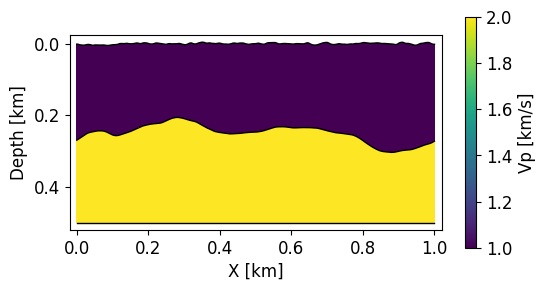

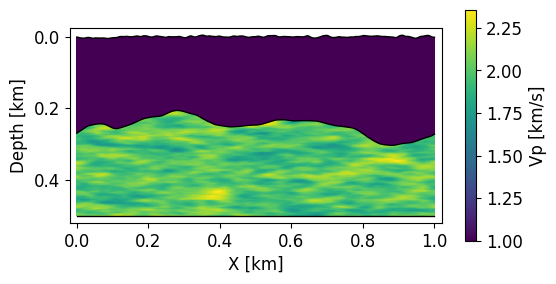

In [3]:
# Define grid for perturbation
grid = xr.DataArray(
    dims=["x"], 
    coords={"x": np.linspace(0.0, 1.0, 251)}
)

# Perturb the top surface
surface = model.surfaces["top"]
surface.perturb(
    std = 0.002,
    L0 = 0.025,
    nu = 1,
    xarr = grid,
    seed = 20
)

# Perturb the middle surface
interface = model.surfaces["interface"]
interface.perturb(
    std = 0.025,
    L0 = 0.25,
    nu = 0.5,
    xarr = grid,
    seed = 15
)

model.plot(property="Vp", figsize=(6,3), aspect="equal")

# Define grid for perturbation
grid = xr.DataArray(
    dims = ["x", "z"], 
    coords = {"x": np.linspace(0.0, 1.0, 501),
              "z": np.linspace(0.0, 0.5, 501)}
)       
 
 # Seed is the random-number generator seed, its value doesn't
 # particularly matter but is fixed here for reproducability
layer2.perturb(
    property = ["Vs", "Vp", "Rho"],
    std = 0.05,
    L0 = 0.025,
    nu = 0.5,
    anisotropy = [5.0, 1.0],
    xarr = grid,
    seed = 12
)

model.plot(property="Vp", figsize=(6,3),aspect="equal")

## Coordinate Frames

Various classes in FrequenSolve have a `frame` attribute. This attribute indicates the frame of reference in
which spatial coordinates are defined. To understand this, consider the domain before surfaces were warped
and after. The materials (and other spatial quantities) can be defined in either configuration and then mapped
to the other (the mapping is defined by linearly interpolating the deformation of the surfaces above and below
the layer). Two options are currently supported:

- `physical` (default): Spatial coordinates correspond to the physical domain.
- `reference`: Spatial coordinates are defined in the reference domain (and subsequently mapped to the physical domain).

The reference configuration can be defined by specifying `z_ref` when defining surfaces in a layered model (`z_ref` 
defaults to the average elevation of the surface over the domain). Changing the solid layer frame to `reference` below 
illustrates the difference.

All frames default to `physical` as it separates surface and velocity model definition. Source and receiver locations can 
be specified in either `reference` or `phyiscal` frame; specifying locations in the reference frame is particularly useful 
for positioning at along the surface, seafloor, or any other surface of interest.

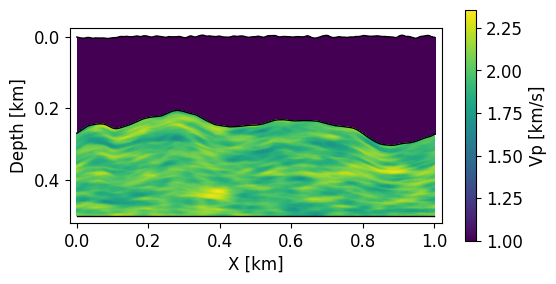

In [4]:
layer2.frame = "reference"
model.plot(
    property = "Vp",
    resolution = [1000,1000],
    figsize = (6,3),
    aspect = "equal"
)

hydrophones = sim.acquisition.receiver_groups["surface"]
hydrophones.frame = "reference"

sources = sim.acquisition.source_groups
sources.frame = "reference"

out = OutputManager()
out += ParaviewOutput(
    name = "simple", 
    fields = ["pressure", "velocity"],
    upscale = 1,
)
sim += out

In [ ]:
project.save()

# site = "local"

# --- Connect to site ---
# if site == "local":
#     site = LocalSite()
# elif site == "stampede3":
#     site = Stampede3Site(rel_path = "FrequenSolve/ex_02/")

site = AWSSite(domain="localhost:5173")

site.sync(project)
    
fd_job = FrequencyDomainJob(
    name = "fd_job",
    simulation = sim,
    f_list = [20.0]
)

simulation_id =site.submit(fd_job, vcpu=4, memory=2048*4)
status = site.wait_for_completion(simulation_id)

if status == "FAILED":
    raise RuntimeError("Simulation failed")

# if site.provisioned:
#     site.submit(fd_job)
# else:
#     site.submit_SLURM(
#         job = fd_job,
#         nodes = 1,
#         queue = "skx-dev",
#         duration = "00-00:01:00",
#     )
#     site.wait_completion(fd_job)

# site.fetch_paraview(fd_job)

INFO: Using cached configuration for localhost:5173
INFO: Using cached credentials
INFO: Stack info loaded: bucket=frequensol-a4282498-1051-7051-e9c9-2a99561fe259-dev-storage
INFO: Syncing project 'ex_02' to S3...
INFO: ✓ Project 'ex_02' synced to S3
INFO: ✓ Synced job file to S3: ex_02/jobs/simple_coupled/fd_job/fd_job.json
INFO: Submitting job via GraphQL API: ex_02/jobs/simple_coupled/fd_job/fd_job.json
INFO: ✓ Simulation submitted
INFO:   Simulation ID: 101cf494-30ba-4873-a81f-6a50834f3481
INFO:   Status: PENDING
INFO: Polling simulation 101cf494-30ba-4873-a81f-6a50834f3481 every 10 seconds (timeout: 3600s)...
INFO: Simulation 101cf494-30ba-4873-a81f-6a50834f3481 completed with status: SUCCEEDED (elapsed: 83s)


AttributeError: 'AWSSite' object has no attribute 'fetch_paraview'

In [ ]:
import pyvista as pv
from pathlib import Path
from frequensolve.util.mesh_convert import convert_gmp

sim = fd_job.simulation
print(sim.mesh)
print(sim.mesh.file)
print(sim.mesh.format)

mesh_path = site.fetch_mesh(fd_job)

# If it's GMP, convert to Gmsh first
if mesh_path.suffix.lower() == ".gmp":
    mesh_path = convert_gmp(mesh_path, mesh_path.with_suffix(".msh"), output_format="gmsh")

mesh = pv.read(str(mesh_path))
plotter = pv.Plotter()
plotter.add_mesh(mesh, show_edges=True, color="white")
plotter.show()